# Part 2 - data analysis

- price level trends
- basic analysis of returns, volatility and risk-return ratio
- correlation and lead-lag analysis
- clustering and cluster analysis (KMeans, hierarchical clustering, HDBSCAN)

### Import the data from Part 1

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('Non-food commodities - Part 1 (data in pct_change).csv')
df_prices=pd.read_csv('Non-food commodities - Part 1 (data in price levels).csv')

C:\WinPython\WPy64-31050\python-3.10.5.amd64\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


# Price level trends

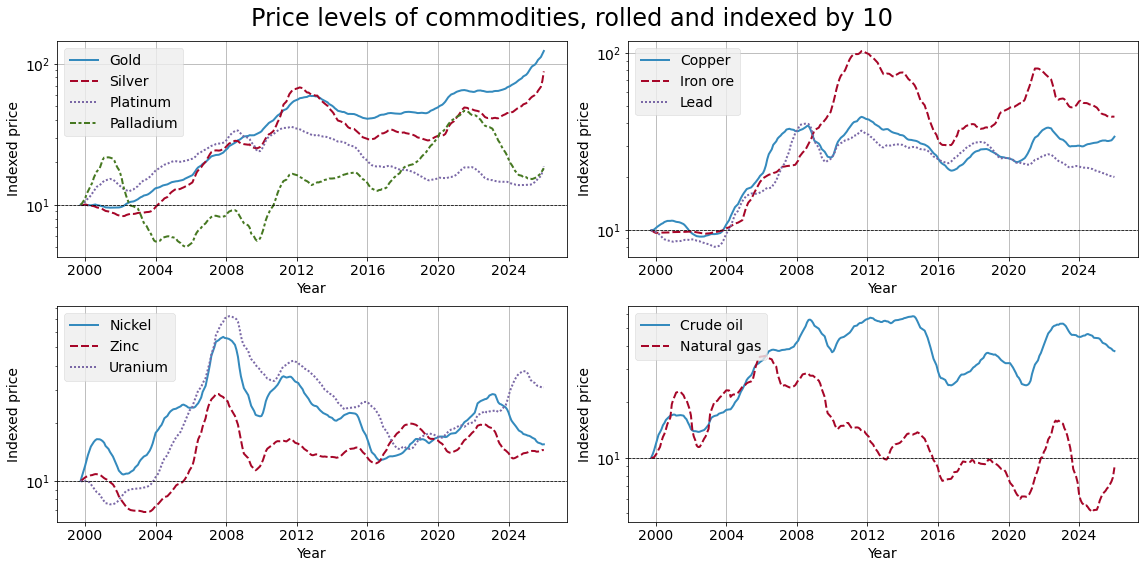

In [2]:
#roll and index the data
df_rolling=df_prices.copy().set_index('Date').rolling(window=12).mean().dropna()
df_rolling.index=pd.to_datetime(df_rolling.index,format='%Y-%m')
df_rolling=df_rolling/df_rolling.iloc[0] *10

#plot the results
fig,axes=plt.subplots(2,2,figsize=(16,8))
plt.style.use("bmh")

sns.lineplot(df_rolling[['Gold','Silver','Platinum','Palladium']],ax=axes[0,0])
sns.lineplot(df_rolling[['Copper','Iron ore','Lead']],ax=axes[0,1])
sns.lineplot(df_rolling[['Nickel','Zinc','Uranium']],ax=axes[1,0])
sns.lineplot(df_rolling[['Crude oil','Natural gas']],ax=axes[1,1])

for i in range(2):
    for j in range(2):
        axes[i,j].axhline(y=10, color="black",linestyle='--',linewidth=0.75)
        axes[i,j].set_yscale('log')
        axes[i,j].set_ylabel('Indexed price',fontsize=14)
        axes[i,j].set_xlabel('Year',fontsize=14)
        axes[i,j].tick_params(axis='x',labelsize=14)
        axes[i,j].tick_params(axis='y',labelsize=14)
        axes[i,j].legend(fontsize=14, loc='upper left')
        axes[i,j].grid(True)

fig.suptitle("Price levels of commodities, rolled and indexed by 10", fontsize=24)
plt.tight_layout()

#uncomment to save for the presentation
plt.savefig("PRICE LEVEL TRENDS.png", dpi=300, bbox_inches="tight",facecolor="white",transparent=False)

plt.show()

### One can observe that all commodities increased in price between 1998 and 2026 except for natural gas

# Risk-return analysis in annual terms

### Represent the data in annual terms

In [3]:
#for returns
df_annual=( (1+df[ df.drop(columns='Date').columns ])
           .groupby(df['Date'].str[:4])
           .prod() 
           - 1)
df_annual=df_annual.reset_index()

#for prices
df_prices_annual=( df_prices[ df_prices.drop(columns='Date').columns ]
                  .groupby(df_prices['Date'].str[:4])
                  .mean() )
df_prices_annual=df_prices_annual.reset_index()

In [4]:
df_annual.head(3)

,Date,Gold,Silver,Platinum,Palladium,Copper,Iron ore,Lead,Nickel,Zinc,Uranium,Crude oil,Natural gas
0,1998,-0.022611,-0.070501,-0.032394,0.174930,-0.108751,-0.005474,-0.041562,-0.062501,-0.043337,-0.175143,-0.250154,-0.126430
1,1999,0.011828,0.063872,0.222509,0.317149,0.164739,-0.133555,-0.068615,1.033957,0.200464,0.105895,1.121911,0.148742
2,2000,-0.062575,-0.140713,0.343245,1.054195,0.014722,0.008921,-0.063925,-0.123563,-0.135918,-0.284184,0.037267,3.405160


In [5]:
df_prices_annual.head(3)

,Date,Gold,Silver,Platinum,Palladium,Copper,Iron ore,Lead,Nickel,Zinc,Uranium,Crude oil,Natural gas
0,1998,9.373550,0.165684,22.714855,19.220705,0.003162,0.000027,0.001016,0.007950,0.001949,0.041948,0.000105,0.000218
1,1999,9.097346,0.170341,24.170884,22.957143,0.003103,0.000024,0.000995,0.011806,0.002123,0.043756,0.000143,0.000232
2,2000,8.932939,0.158182,33.365895,42.958426,0.003470,0.000024,0.000867,0.016755,0.002172,0.035443,0.000217,0.000463


### Mean vs median annual return analysis

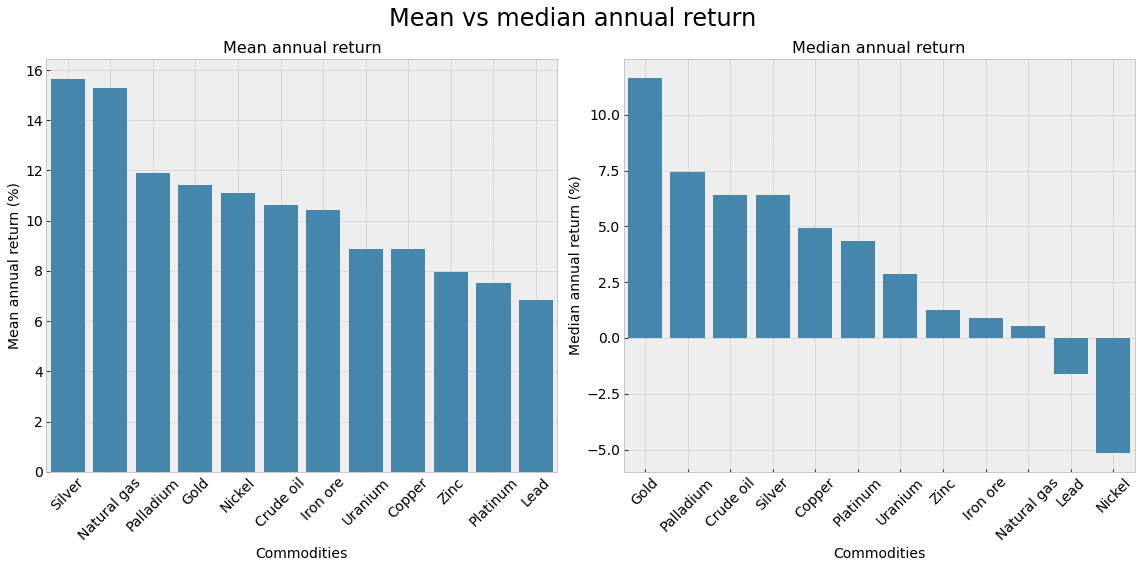

In [6]:
fig,axes=plt.subplots(1,2,figsize=(16,8))
plt.style.use("bmh")

mean_annual_return=df_annual.drop(columns='Date').mean().sort_values(ascending=False)*100
median_annual_return=df_annual.drop(columns='Date').median().sort_values(ascending=False)*100

sns.barplot(x=mean_annual_return.index,y=mean_annual_return.values,ax=axes[0])
sns.barplot(x=median_annual_return.index,y=median_annual_return.values,ax=axes[1])

for j in range(2):
    if j==0:
        axes[j].set_ylabel('Mean annual return (%)',fontsize=14)
        axes[j].set_title('Mean annual return',fontsize=16)
    if j==1:
        axes[j].set_ylabel('Median annual return (%)',fontsize=14)
        axes[j].set_title('Median annual return',fontsize=16)
    axes[j].set_xlabel('Commodities',fontsize=14)
    axes[j].tick_params(axis='x',labelsize=14,rotation=45)
    axes[j].tick_params(axis='y',labelsize=14)    
    axes[j].set_axisbelow(True)
    axes[j].grid(True)
    
fig.suptitle("Mean vs median annual return", fontsize=24)
plt.tight_layout()

#uncomment to save for the presentation
plt.savefig("MEAN VS MEDIAN.png", dpi=300, bbox_inches="tight",facecolor="white",transparent=False)

plt.show()

### This comparison underlines that the return for some commodities is strongly dependent on outliers and is less stable than for other commodities (e. g. natural gas vs gold)

### Volatility analysis

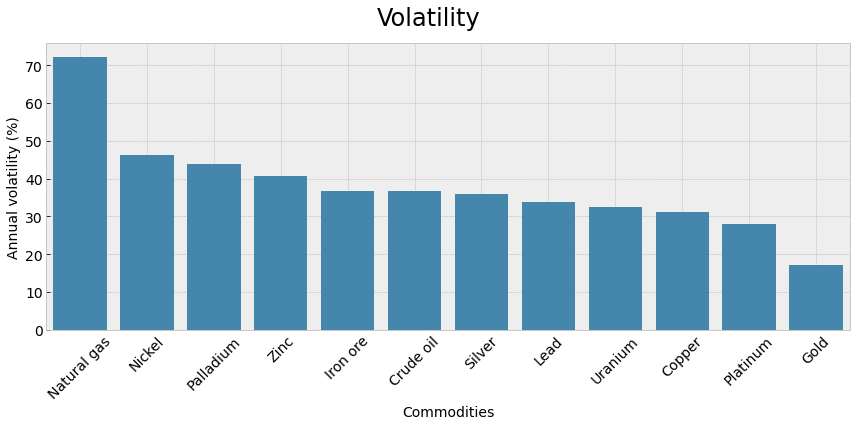

In [7]:
fig,axes=plt.subplots(1,1,figsize=(12,6))
plt.style.use("bmh")

annual_volatility=df_annual.drop(columns='Date').std().sort_values(ascending=False)*100

sns.barplot(x=annual_volatility.index,y=annual_volatility.values)

axes.set_ylabel('Annual volatility (%)',fontsize=14)
axes.set_xlabel('Commodities',fontsize=14)
axes.tick_params(axis='x',labelsize=14,rotation=45)
axes.tick_params(axis='y',labelsize=14)
axes.set_axisbelow(True)
axes.grid(True)

fig.suptitle("Volatility", fontsize=24)
plt.tight_layout()

#uncomment to save for the presentation
plt.savefig("VOLATILITY.png", dpi=300, bbox_inches="tight",facecolor="white",transparent=False)

plt.show()

### One may observe that the most volatile commodities are primarily the ones related to energy or industry

### Risk-return analysis

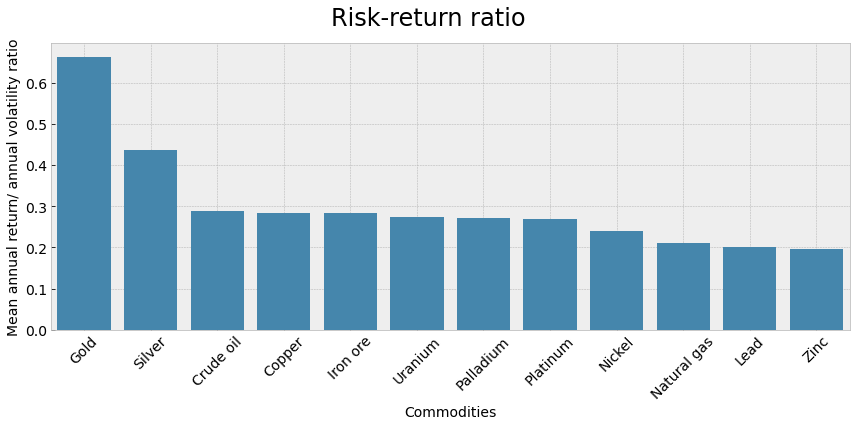

In [8]:
fig,axes=plt.subplots(1,1,figsize=(12,6))
plt.style.use("bmh")

return_volatility_ratio_annual=mean_annual_return/annual_volatility
return_volatility_ratio_annual=return_volatility_ratio_annual.sort_values(ascending=False)

sns.barplot(x=return_volatility_ratio_annual.index,y=return_volatility_ratio_annual.values)

axes.set_ylabel('Mean annual return/ annual volatility ratio',fontsize=14)
axes.set_xlabel('Commodities',fontsize=14)
axes.tick_params(axis='x',labelsize=14,rotation=45)
axes.tick_params(axis='y',labelsize=14)
axes.set_axisbelow(True)
axes.grid(True)
    
fig.suptitle("Risk-return ratio", fontsize=24)
plt.tight_layout()

#uncomment to save for the presentation
plt.savefig("RISK-RETURN RATIO.png", dpi=300, bbox_inches="tight",facecolor="white",transparent=False)

plt.show()

### This graph emphasizes that precious metals (e. g. gold and silver) have the best risk-return ratio, followed by industrial materials and energy commodities

# Correlation analysis

### For returns

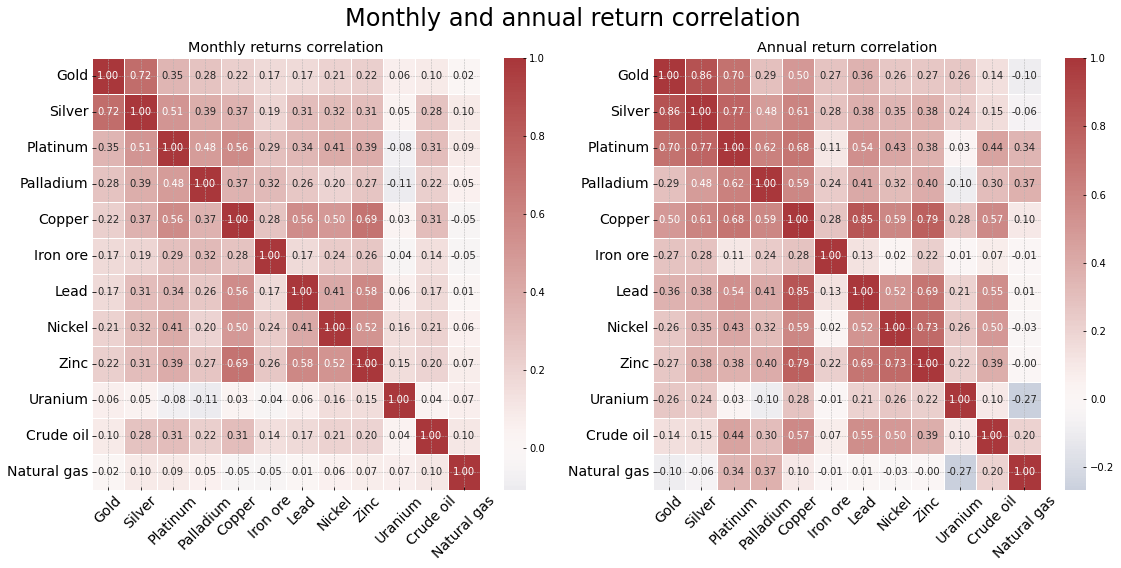

In [9]:
corr_return=df.drop(columns='Date').corr()
corr_return_annual=(df_annual.drop(columns='Date')).corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
plt.style.use('bmh')

sns.heatmap(corr_return,annot=True,cmap='vlag',center=0,linewidth=1,fmt=".2f",ax=axes[0])
sns.heatmap(corr_return_annual,annot=True,cmap='vlag',center=0,linewidth=1,fmt=".2f",ax=axes[1])

for j in range(2):
    axes[j].tick_params(axis='x',labelsize=14,rotation=45)
    axes[j].tick_params(axis='x',labelsize=14,rotation=45)
    axes[j].tick_params(axis='y',labelsize=14)
    axes[j].tick_params(axis='y',labelsize=14)
        
axes[0].set_title('Monthly returns correlation')
axes[1].set_title('Annual return correlation')

fig.suptitle("Monthly and annual return correlation", fontsize=24)
plt.tight_layout()

#uncomment to save for the presentation
plt.savefig("MONTHLY VS ANNUAL RETURN CORRELATION.png", dpi=300, bbox_inches="tight",facecolor="white",transparent=False)

plt.show()


In [10]:
precious_metals=['Gold','Silver','Platinum','Palladium']
industrial_materials=['Copper','Iron ore','Lead','Nickel','Zinc','Uranium']
energy_materials=['Crude oil','Natural gas']

In [11]:
df_annual.drop(columns='Date').corr().loc[precious_metals,precious_metals]

,Gold,Silver,Platinum,Palladium
Gold,1.000000,0.862895,0.698731,0.294320
Silver,0.862895,1.000000,0.766000,0.479744
Platinum,0.698731,0.766000,1.000000,0.623343
Palladium,0.294320,0.479744,0.623343,1.000000


In [12]:
df_annual.drop(columns='Date').corr().loc[industrial_materials,industrial_materials]

,Copper,Iron ore,Lead,Nickel,Zinc,Uranium
Copper,1.000000,0.279423,0.846889,0.587679,0.790212,0.276758
Iron ore,0.279423,1.000000,0.130798,0.023112,0.223062,-0.005931
Lead,0.846889,0.130798,1.000000,0.519294,0.687223,0.213137
Nickel,0.587679,0.023112,0.519294,1.000000,0.733287,0.260950
Zinc,0.790212,0.223062,0.687223,0.733287,1.000000,0.223680
Uranium,0.276758,-0.005931,0.213137,0.260950,0.223680,1.000000


In [13]:
df_annual.drop(columns='Date').corr().loc[energy_materials,energy_materials]

,Crude oil,Natural gas
Crude oil,1.000000,0.204568
Natural gas,0.204568,1.000000


### We observe that usually the prices of precious metals move together in the same direction, whereas the same thing is true only for some industrial materials and energy commodities such as oil and gas demonstrate a rather weak return correlation

# Clustering

# KMeans

### Finding the best parameter k for clustering via KMeans

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [15]:
X=df.drop(columns='Date').T

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

#getting the best parameter k using elbow method and silhouette_score
inertia=[]
silhouette_scores=[]

for k in range(1,len(X)):
    kmeans=KMeans(n_clusters=k, random_state=42, n_init=50)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    if k>1:
        labels=kmeans.predict(X_scaled)
        silhouette_scores.append(silhouette_score(X_scaled,labels))

df_k_inertia=pd.DataFrame({'k':list(range(1,len(X))),
                            'inertia':inertia})
df_k_inertia['improvement']=-df_k_inertia['inertia'].diff()
df_k_inertia['improvement gain']=-df_k_inertia['improvement'].diff()
best_k_elbow=df_k_inertia.loc[df_k_inertia['improvement gain'].idxmax(),'k']

df_k_silhouette=pd.DataFrame({'k':list(range(2,len(X))),
                             'silhouette_score':silhouette_scores})
best_k_silh=df_k_silhouette.loc[df_k_silhouette['silhouette_score'].idxmax(),'k']

print('According to the elbow method, the best parameter k is ',best_k_elbow)
print('According to silhouette_score, the best parameter k is ',best_k_silh)

According to the elbow method, the best parameter k is  3
According to silhouette_score, the best parameter k is  2


In [16]:
df_k_inertia[['k','improvement gain']].sort_values(by='improvement gain',ascending=False).head(3)

,k,improvement gain
2,3,520.527024
7,8,76.351700
5,6,62.149771


In [17]:
df_k_silhouette[['k','silhouette_score']].sort_values(by='silhouette_score',ascending=False).head(3)

,k,silhouette_score
0,2,0.363677
1,3,0.172042
2,4,0.171912


### Proceed with clustering the data via KMeans with k=2 and k=3

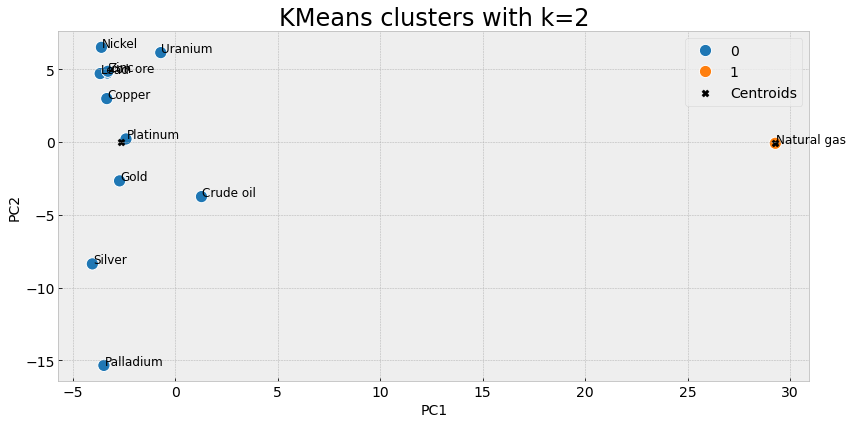

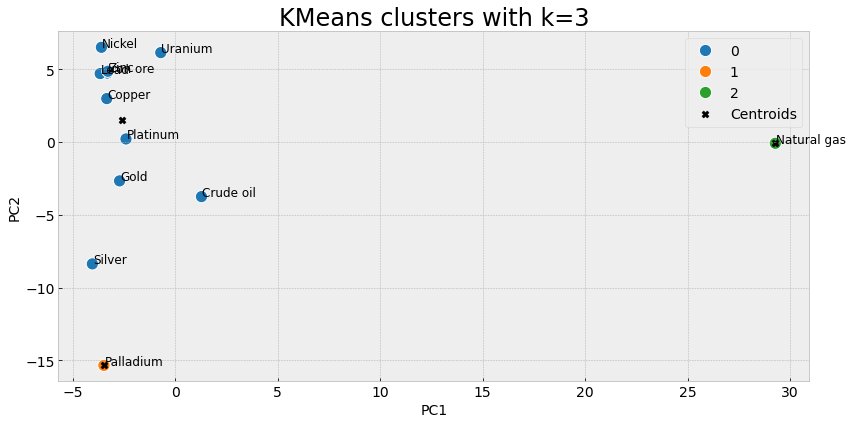

In [18]:
from sklearn.preprocessing import StandardScaler

data_frames_storage_kmeans={}

for k in [2,3]:
    X=df.drop(columns='Date').T
    scaler=StandardScaler()
    X_scaled=scaler.fit_transform(X)

    #KMeans
    kmeans=KMeans(n_clusters=k, random_state=42, n_init=50)
    kmeans.fit(X_scaled)
    target=kmeans.predict(X_scaled)

    clusters=pd.DataFrame({'Commodity':X.index,
                          'Cluster':target})
    
    #PCA plot
    pca=PCA(n_components=2)
    X_pca=pca.fit_transform(X_scaled)

    df_plot=pd.DataFrame({'Commodity':X.index,
                         'PC1':X_pca[:,0],
                         'PC2':X_pca[:,1],
                         'Cluster':target})
    centroids_pca = pca.transform(kmeans.cluster_centers_)
    
    plt.figure(figsize=(12,6))
    plt.style.use('bmh')
    
    sns.scatterplot(data=df_plot,x='PC1',y='PC2',hue='Cluster',s=150,palette='tab10')
    plt.scatter(centroids_pca[:, 0],centroids_pca[:, 1],marker='X',s=50,color='black',label='Centroids')
    for _, row in df_plot.iterrows():
        plt.text(row['PC1']+0.03,row['PC2']+0.03,row['Commodity'],fontsize=12)
    
    plt.xlabel('PC1',fontsize=14)
    plt.ylabel('PC2',fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=14)
    plt.grid(True)
    
    plt.title(f'KMeans clusters with k={k}',fontsize=24)
    plt.tight_layout()
    
    #uncomment to save for the presentation
    plt.savefig(f"KMeans cluster, k={k}.png", dpi=300, bbox_inches="tight",facecolor="white",transparent=False)
    
    plt.show()
    
    #cluster features
    df_annual_clusters_kmeans={}

    cluster_id=[]
    cluster_size=[]
    cluster_mean=[]
    cluster_median=[]
    cluster_volatility=[]
    cluster_members=[]

    for i in clusters['Cluster'].unique():

        cluster_id.append(i)
        
        cluster_members.append(clusters[clusters['Cluster']==i]['Commodity'].values)

        cluster_size.append(clusters['Cluster'].value_counts().sort_index()[i])

        df_annual_cluster=df_annual[clusters[clusters['Cluster']==i]['Commodity'].values]

        cluster_mean.append(df_annual_cluster.stack().mean())

        cluster_median.append(df_annual_cluster.stack().median())

        cluster_volatility.append(df_annual_cluster.stack().std())

    df_annual_clusters_kmeans=pd.DataFrame({'Cluster':cluster_id,
                                     'Cluster members': cluster_members ,
                                    'Cluster size':cluster_size,
                                    'Cluster mean':cluster_mean,
                                    'Cluster median':cluster_median,
                                    'Cluster volatility':cluster_volatility})
    df_annual_clusters_kmeans['Risk-return ratio']=df_annual_clusters_kmeans['Cluster mean']/df_annual_clusters_kmeans['Cluster volatility']
    df_annual_clusters_kmeans=df_annual_clusters_kmeans.sort_values(by='Cluster',ascending=True)

    data_frames_storage_kmeans[f'{k}']=df_annual_clusters_kmeans

In [19]:
data_frames_storage_kmeans['2']

,Cluster,Cluster members,Cluster size,Cluster mean,Cluster median,Cluster volatility,Risk-return ratio
0,0,"[Gold, Silver, Platinum, Palladium, Copper, Ir...",11,0.101037,0.035702,0.351538,0.287413
1,1,[Natural gas],1,0.152943,0.005453,0.721753,0.211905


In [20]:
data_frames_storage_kmeans['3']

,Cluster,Cluster members,Cluster size,Cluster mean,Cluster median,Cluster volatility,Risk-return ratio
0,0,"[Gold, Silver, Platinum, Copper, Iron ore, Lea...",10,0.099242,0.031360,0.342600,0.289673
1,1,[Palladium],1,0.118981,0.074273,0.437793,0.271775
2,2,[Natural gas],1,0.152943,0.005453,0.721753,0.211905


In [21]:
print('Explained variance is approximately',(pca.explained_variance_ratio_.sum()*100).round(2),'%')

Explained variance is approximately 43.63 %


### For both k=2 and k=3, KMeans managed to identify certain outliers, yet failed to group other commodities in meaningful clusters. Thus, we shall proceed with another method such as hierarchical clustering.

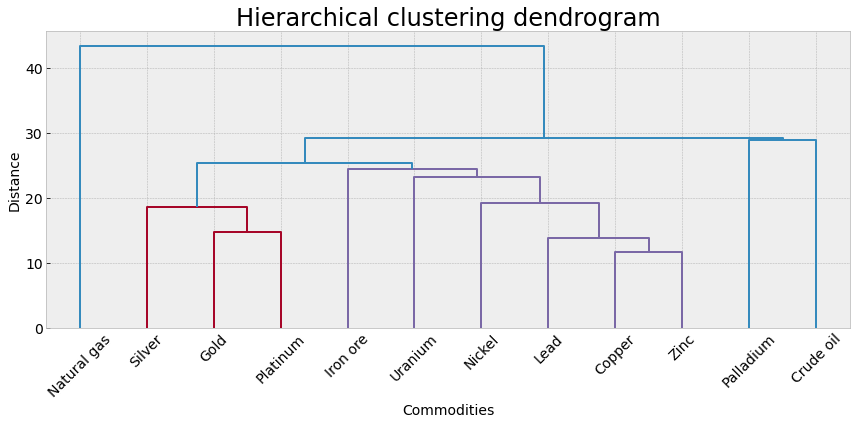

In [22]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

#hierarchical clustering
X=df.drop(columns='Date').T
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
Z = linkage(X_scaled, method='ward')

#dendrogram
plt.figure(figsize=(12, 6))
plt.style.use('bmh')

dendrogram(Z, labels=X.index, leaf_rotation=45,color_threshold=25)
labels = fcluster(Z, t=25, criterion='distance')

plt.ylabel('Distance',fontsize=14)
plt.xlabel('Commodities',fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.title('Hierarchical clustering dendrogram',fontsize=24)
plt.tight_layout()

#uncomment to save for the presentation
plt.savefig("DENDROGRAM.png", dpi=300, bbox_inches="tight",facecolor="white",transparent=False)

plt.show()

clusters_hier=pd.DataFrame({'Commodity':X.index,
                          'Cluster':labels})

#cluster features    
df_annual_clusters_hier={}

cluster_id=[]
cluster_size=[]
cluster_mean=[]
cluster_median=[]
cluster_volatility=[]
cluster_members=[]

for i in clusters_hier['Cluster'].unique():

    cluster_id.append(i)
        
    cluster_members.append(clusters_hier[clusters_hier['Cluster']==i]['Commodity'].values)

    cluster_size.append(clusters_hier['Cluster'].value_counts().sort_index()[i])

    df_annual_cluster=df_annual[clusters_hier[clusters_hier['Cluster']==i]['Commodity'].values]

    cluster_mean.append(df_annual_cluster.stack().mean())

    cluster_median.append(df_annual_cluster.stack().median())

    cluster_volatility.append(df_annual_cluster.stack().std())

df_annual_clusters_hier=pd.DataFrame({'Cluster':cluster_id,
                                     'Cluster members': cluster_members ,
                                    'Cluster size':cluster_size,
                                    'Cluster mean':cluster_mean,
                                    'Cluster median':cluster_median,
                                    'Cluster volatility':cluster_volatility})
df_annual_clusters_hier['Risk-return ratio']=df_annual_clusters_hier['Cluster mean']/df_annual_clusters_hier['Cluster volatility']
df_annual_clusters_hier=df_annual_clusters_hier.sort_values(by='Cluster',ascending=True)

In [23]:
df_annual_clusters_hier.head()

,Cluster,Cluster members,Cluster size,Cluster mean,Cluster median,Cluster volatility,Risk-return ratio
0,1,"[Gold, Silver, Platinum]",3,0.115206,0.067603,0.279600,0.412038
2,2,"[Copper, Iron ore, Lead, Nickel, Zinc, Uranium]",6,0.090066,0.017005,0.367502,0.245076
1,3,[Palladium],1,0.118981,0.074273,0.437793,0.271775
3,4,[Crude oil],1,0.106408,0.064118,0.368149,0.289036
4,5,[Natural gas],1,0.152943,0.005453,0.721753,0.211905


### We observe that hierarchical clustering created the following groups:

- Cluster 1: Precious metals (gold, silver, platinum)
- Cluster 2: Industrial commodities (copper, iron ore, lead, nickel, zinc, uranium)
- Cluster 3: Outlier (crude oil)
- Cluster 4: Outlier (palladium)
- Cluster 5: Outlier (natural gas).

We will name clusters respectively.

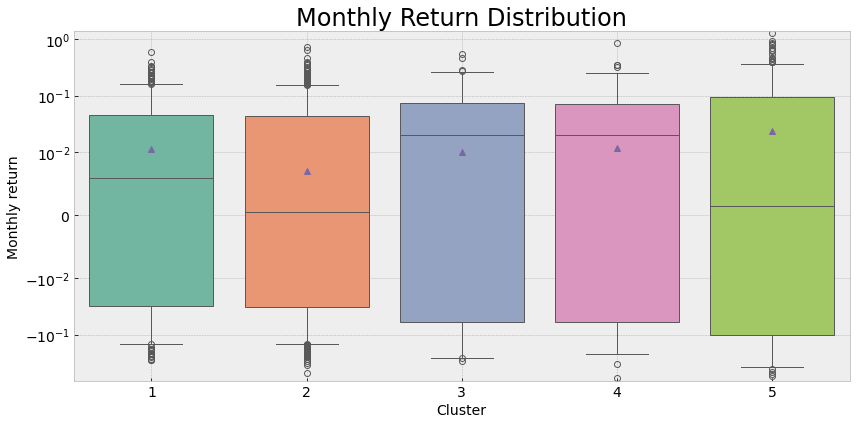

In [24]:
#boxplot
df_box=[]
for i in clusters_hier['Cluster'].unique():
    
    name=clusters_hier[clusters_hier['Cluster']==i]['Commodity'].values
    
    df_0=df[name].melt(var_name='Commodity',value_name='Monthly return')
    
    df_0['Cluster']=i
    df_box.append(df_0)

df_box = pd.concat(df_box, ignore_index=True)

plt.figure(figsize=(12, 6))
plt.style.use("bmh")

sns.boxplot(data=df_box,x='Cluster',y='Monthly return',showmeans=True,palette="Set2",hue='Cluster',legend=False)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Cluster',fontsize=14)
plt.ylabel('Monthly return',fontsize=14)

plt.grid(True)
plt.yscale('symlog',linthresh=0.01)

plt.title('Monthly Return Distribution',fontsize=24)
plt.tight_layout()

#uncomment to save for the presentation
plt.savefig("BOXPLOT.png", dpi=300, bbox_inches="tight",facecolor="white",transparent=False)

plt.show()

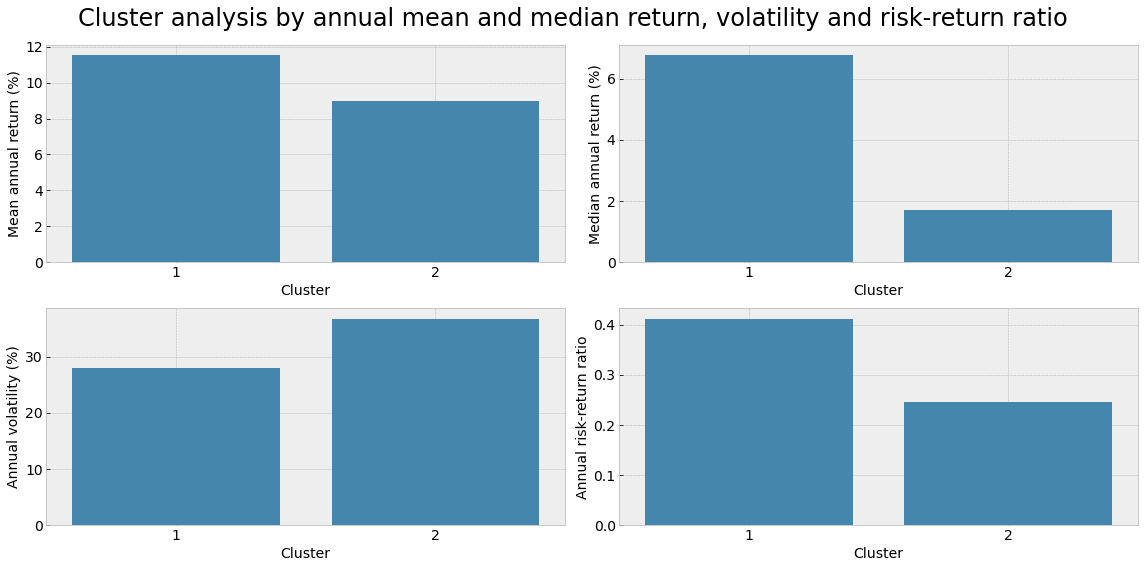

In [25]:
fig,axes=plt.subplots(2,2,figsize=(16,8))
plt.style.use("bmh")

df_annual_clusters_hier0=df_annual_clusters_hier[ (df_annual_clusters_hier['Cluster']==1) | (df_annual_clusters_hier['Cluster']==2)]

cluster_mean_percent=(df_annual_clusters_hier0.set_index('Cluster')['Cluster mean']*100)
cluster_median_percent=(df_annual_clusters_hier0.set_index('Cluster')['Cluster median']*100)
cluster_volatility_percent=(df_annual_clusters_hier0.set_index('Cluster')['Cluster volatility']*100)
cluster_risk_return_ratio_percent=(df_annual_clusters_hier0.set_index('Cluster')['Risk-return ratio'])

sns.barplot(x=cluster_mean_percent.index,y=cluster_mean_percent.values,ax=axes[0,0])
sns.barplot(x=cluster_median_percent.index,y=cluster_median_percent.values,ax=axes[0,1])
sns.barplot(x=cluster_volatility_percent.index,y=cluster_volatility_percent.values,ax=axes[1,0])
sns.barplot(x=cluster_risk_return_ratio_percent.index, y=cluster_risk_return_ratio_percent.values,ax=axes[1,1])

for i in range(2):
    for j in range(2):
        axes[i,j].set_xlabel('Cluster',fontsize=14)
        axes[i,j].tick_params(axis='x',labelsize=14)
        axes[i,j].tick_params(axis='y',labelsize=14)
        axes[i,j].set_axisbelow(True)
        axes[i,j].grid(True)

axes[0,0].set_ylabel('Mean annual return (%)',fontsize=14)
axes[0,1].set_ylabel('Median annual return (%)',fontsize=14)
axes[1,0].set_ylabel('Annual volatility (%)',fontsize=14)
axes[1,1].set_ylabel('Annual risk-return ratio',fontsize=14)

fig.suptitle("Cluster analysis by annual mean and median return, volatility and risk-return ratio", fontsize=24)
plt.tight_layout()

#uncomment to save for the presentation
plt.savefig("CLUSTER ANALYSIS .png", dpi=300, bbox_inches="tight",facecolor="white",transparent=False)

plt.show()

### We observe that the gap between the mean annual returns for precious metals and industrial materials and the median annual return for precious metals and industrial materials is large, indicating high volatility and dependence on outliers. Annual risk-return ratio for precious metals is almost double the one for industrial materials, emphasizing that precious metals are a better investment

# Lead-lag analysis

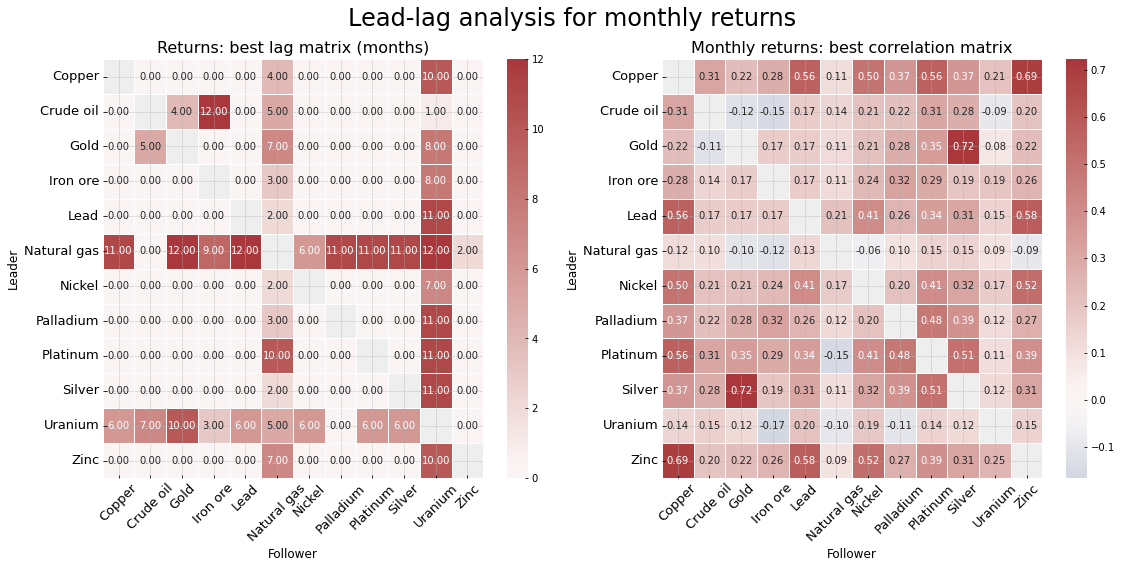

In [26]:
#best lag for returns
max_lag=12
commodities=df.drop(columns='Date').columns
results_lags=[]
results_corrs=[]
for leader in commodities:
    for follower in commodities:
        if leader==follower:
            continue
        corr_initial=df[leader].corr(df[follower])
        best_lag=0
        best_corr=corr_initial
        for lag in range(1,max_lag+1):
            corr=df[leader].shift(lag).corr(df[follower])
            if abs(corr)>abs(best_corr):
                best_lag=lag
                best_corr=corr
        results_lags.append({'Leader':leader,'Follower':follower,'Best lag':best_lag})
        results_corrs.append({'Leader':leader,'Follower':follower,'Best corr.':best_corr})
lags_time_months=pd.DataFrame(results_lags)
lags_corr_months=pd.DataFrame(results_corrs)

#plot
import numpy as np

best_lag_matrix_months=lags_time_months.pivot(index='Leader',columns='Follower',values='Best lag')
best_corr_matrix_months=lags_corr_months.pivot(index='Leader',columns='Follower',values='Best corr.')

fig,axes=plt.subplots(1,2,figsize=(16,8))
plt.style.use("bmh")

sns.heatmap(best_lag_matrix_months,annot=True,cmap='vlag',center=0,linewidth=1,fmt=".2f",ax=axes[0])
sns.heatmap(best_corr_matrix_months,annot=True,cmap='vlag',center=0,linewidth=1,fmt=".2f",ax=axes[1])

for j in range(2):
    axes[j].tick_params(axis='x',rotation=45,labelsize=13)
    axes[j].tick_params(axis='y',labelsize=13)

axes[0].set_title('Returns: best lag matrix (months)',fontsize=16)
axes[1].set_title('Monthly returns: best correlation matrix',fontsize=16)

fig.suptitle("Lead-lag analysis for monthly returns", fontsize=24)
plt.tight_layout()

#uncomment to save for the presentation
plt.savefig("LEAD LAG ANALYSIS.png", dpi=300, bbox_inches="tight",facecolor="white",transparent=False)

plt.show()

# For example:

### - Leader: Uranium
### - Follower: Natural gas
### - Best lag: 5
### - Best corr. : -0.10

### means that the correlation between the monthly return for uranium lagged by 5 months and the monthly return for natural gas at the current moment is -0.10

### The lead-lag analysis is exploratory. It identifies commodity pairs where lagged return correlations are stronger than same-month correlations, but the results should not be interpreted as causal relationships without further statistical testing.

### For the further time series analysis we proceed with two clusters which we have identified via hierarchical clustering. We shall redesign the data respectively.

In [27]:
Cluster1=clusters_hier[clusters_hier['Cluster']==1]

Cluster2=clusters_hier[clusters_hier['Cluster']==2]

df_c1=pd.DataFrame({'Date':df['Date'],
                   'Return':df[Cluster1['Commodity']].mean(axis=1)})
df_c1_prices=pd.DataFrame({'Date':df_prices['Date'],
                   'Price':df_prices[Cluster1['Commodity']].mean(axis=1)})
df_c1_annual=pd.DataFrame({'Date':df_annual['Date'],
                   'Return':df_annual[Cluster1['Commodity']].mean(axis=1)})

df_c2=pd.DataFrame({'Date':df['Date'],
                   'Return':df[Cluster2['Commodity']].mean(axis=1)})
df_c2_prices=pd.DataFrame({'Date':df_prices['Date'],
                   'Price':df_prices[Cluster2['Commodity']].mean(axis=1)})
df_c2_annual=pd.DataFrame({'Date':df_annual['Date'],
                   'Return':df_annual[Cluster2['Commodity']].mean(axis=1)})

### Analyzing rolling price, rolling return and rolling volatility

In [28]:
#prices
df_c1_prices_rolling=df_c1_prices.set_index('Date').rolling(12).mean().dropna()
df_c1_prices_rolling.index=pd.to_datetime(df_c1_prices_rolling.index,format='%Y-%m')
df_c1_prices_rolling['Price']=df_c1_prices_rolling['Price']/ (df_c1_prices_rolling['Price'].iloc[0]) * 1

df_c2_prices_rolling=df_c2_prices.set_index('Date').rolling(12).mean().dropna()
df_c2_prices_rolling.index=pd.to_datetime(df_c2_prices_rolling.index,format='%Y-%m')
df_c2_prices_rolling['Price']=df_c2_prices_rolling['Price']/ (df_c2_prices_rolling['Price'].iloc[0]) * 1

#monthly returns
df_c1_rolling=df_c1.set_index('Date').rolling(12).mean().dropna()*100
df_c1_rolling.index=pd.to_datetime(df_c1_rolling.index,format='%Y-%m')

df_c2_rolling=df_c2.set_index('Date').rolling(12).mean().dropna()*100
df_c2_rolling.index=pd.to_datetime(df_c2_rolling.index,format='%Y-%m')

#monthly volatility
df_c1_volat_rolling=df_c1.set_index('Date').rolling(12).std().dropna()*100
df_c1_volat_rolling.index=pd.to_datetime(df_c1_volat_rolling.index,format='%Y-%m')

df_c2_volat_rolling=df_c2.set_index('Date').rolling(12).std().dropna()*100
df_c2_volat_rolling.index=pd.to_datetime(df_c2_volat_rolling.index,format='%Y-%m')

#risk-return ratio
df_c1_risk_return_ratio=df_c1_rolling/df_c1_volat_rolling
df_c2_risk_return_ratio=df_c2_rolling/df_c2_volat_rolling

#C1/C2 ratio
cluster_prices_ratio=(
    (df_c1_prices['Price']/df_c2_prices['Price'])/((df_c1_prices['Price']/df_c2_prices['Price']).iloc[0]) )

df_cluster_prices_ratio=pd.DataFrame({'Date':df_c1_prices['Date'],
                                     'Ratio':cluster_prices_ratio})
df_cluster_prices_ratio=df_cluster_prices_ratio.set_index('Date').rolling(12).mean().dropna()
df_cluster_prices_ratio.index=pd.to_datetime(df_cluster_prices_ratio.index,format='%Y-%m')

#drawdown
df_rolling_max_c1=df_c1_prices.set_index('Date').rolling(12).max()
dummy_df_c1=df_c1_prices.set_index('Date')
drawdown_c1=((dummy_df_c1/df_rolling_max_c1 - 1)*100).dropna()
drawdown_c1.index=pd.to_datetime(drawdown_c1.index,format='%Y-%m')

df_rolling_max_c2=df_c2_prices.set_index('Date').rolling(12).max()
dummy_df_c2=df_c2_prices.set_index('Date')
drawdown_c2=((dummy_df_c2/df_rolling_max_c2 - 1)*100).dropna()
drawdown_c2.index=pd.to_datetime(drawdown_c2.index,format='%Y-%m')

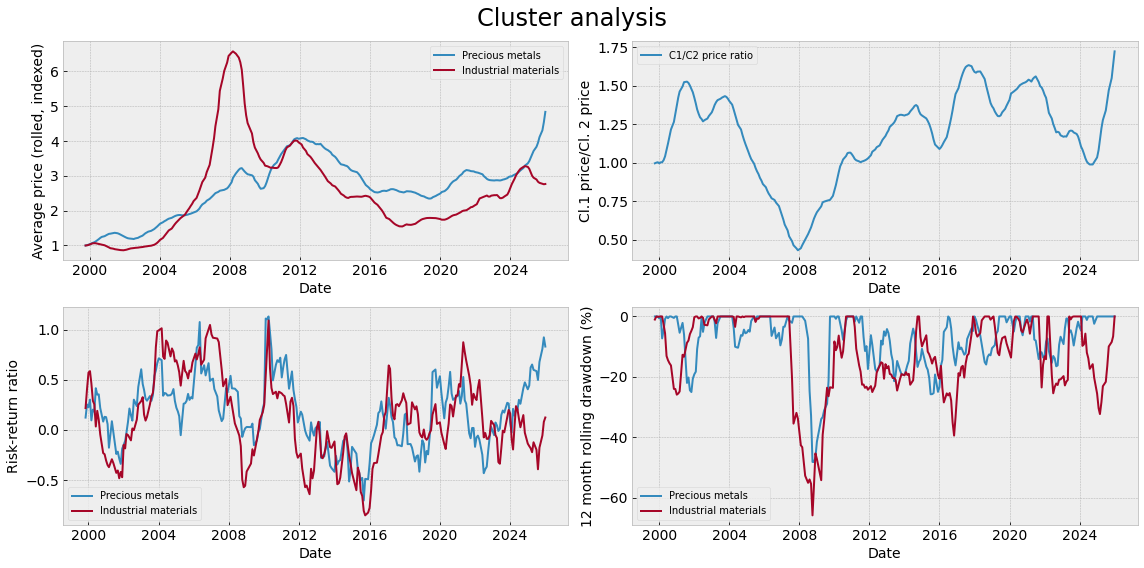

In [29]:
fig,axes=plt.subplots(2,2,figsize=(16,8))
plt.style.use("bmh")

sns.lineplot(data=df_c1_prices_rolling,x='Date',y='Price',ax=axes[0,0],label='Precious metals')
sns.lineplot(data=df_c2_prices_rolling,x='Date',y='Price',ax=axes[0,0],label='Industrial materials')
axes[0,0].set_ylabel('Average price (rolled, indexed)',fontsize=14)

sns.lineplot(data=df_cluster_prices_ratio,x='Date',y='Ratio',ax=axes[0,1],label='C1/C2 price ratio')
axes[0,1].set_ylabel('Cl.1 price/Cl. 2 price',fontsize=14)

sns.lineplot(data=df_c1_risk_return_ratio,x='Date',y='Return',ax=axes[1,0],label='Precious metals')
sns.lineplot(data=df_c2_risk_return_ratio,x='Date',y='Return',ax=axes[1,0],label='Industrial materials')
axes[1,0].set_ylabel('Risk-return ratio',fontsize=14)

sns.lineplot(data=drawdown_c1,x='Date',y='Price',ax=axes[1,1],label='Precious metals')
sns.lineplot(data=drawdown_c2,x='Date',y='Price',ax=axes[1,1],label='Industrial materials')
axes[1,1].set_ylabel('12 month rolling drawdown (%)',fontsize=14)

for i in range(2):
    for j in range(2):
        axes[i,j].set_xlabel('Date',fontsize=14)
        axes[i,j].tick_params(axis='x',labelsize=14)
        axes[i,j].tick_params(axis='y',labelsize=14)
        axes[i,j].grid(True)
        
fig.suptitle("Cluster analysis", fontsize=24)
plt.tight_layout()

#uncomment to save for the presentation
plt.savefig("CLUSTER ANALYSIS (CONTINUATION).png", dpi=300, bbox_inches="tight",facecolor="white",transparent=False)

plt.show()

### We see that in the long run, the price of the precious metals is higher as compared to the average price of the industrial materials. Risk-return ratio for both clusters behaves similarly during the times of strong crises with a slight lag. The drawdown graph demonstrates that potential losses from investing in industrial materials are higher as compared to the precious metals.

In [30]:
df_annual_clusters_hier0=df_annual_clusters_hier0.sort_values(by='Cluster',ascending=True)
df_annual_clusters_hier0['Maximum 12 month rolling drawdown (monthly)']=[drawdown_c1.min().iloc[0]/100,drawdown_c2.min().iloc[0]/100]
df_annual_clusters_hier0['Mean 12 month rolling drawdown (monthly)']=[drawdown_c1.mean().iloc[0]/100,drawdown_c2.mean().iloc[0]/100]
df_annual_clusters_hier0

,Cluster,Cluster members,Cluster size,Cluster mean,Cluster median,Cluster volatility,Risk-return ratio,Maximum 12 month rolling drawdown (monthly),Mean 12 month rolling drawdown (monthly)
0,1,"[Gold, Silver, Platinum]",3,0.115206,0.067603,0.279600,0.412038,-0.481940,-0.074495
2,2,"[Copper, Iron ore, Lead, Nickel, Zinc, Uranium]",6,0.090066,0.017005,0.367502,0.245076,-0.658699,-0.120843


- PM - precious metals
- IM - industrial materials

# Summary for cluster characteristics:

### Precious metals:

- High mean and median returns
- Medium volatility and medium drawdowns
- Good risk-return ratio

### Industrial materials:

- Large gap between the mean and the median returns
- Medium-high volatility and high drawdowns
- Medium risk-return ratio

### Tuning HDBSCAN parameters

In [31]:
import hdbscan

df_clusters=df_c1.copy()
df_clusters=df_c1.merge(df_c2,on='Date',how='inner')
df_clusters=df_clusters.rename(columns={'Return_x':'PM','Return_y':'IM'})

X=df_clusters.drop(columns='Date')
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

N=12

parameters={}
mean=[]
params=[]
noise=[]

for i in range(2,N):
    for j in range(1,i+1):
        clusterer=hdbscan.HDBSCAN(min_cluster_size=i,min_samples=j)
        clusters0=clusterer.fit_predict(X_scaled)
        
        mean_cluster_persistence=clusterer.cluster_persistence_.mean()
        
        mean.append(mean_cluster_persistence)
        params.append((i,j))
        noise.append( (clusters0==-1).sum()/len(clusters0) )

parameters=pd.DataFrame({'Parameters':params,
                        'Mean cluster persistence':mean,
                        'Noise':noise})

idx=parameters[parameters['Noise']<0.5]['Mean cluster persistence'].idxmax()
best_parameters=parameters.loc[idx,'Parameters']

### Now we perform HDBSCAN clustering with respect to months

In [32]:
import hdbscan

i,j=best_parameters

df_clusters=df_c1.copy()
df_clusters=df_c1.merge(df_c2,on='Date',how='inner')
df_clusters=df_clusters.rename(columns={'Return_x':'PM','Return_y':'IM'})

X=df_clusters.drop(columns='Date')
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

clusterer=hdbscan.HDBSCAN(min_cluster_size=i,min_samples=j)
clusters0=clusterer.fit_predict(X_scaled)

df_clusters_hdbscan=df_clusters.copy()
df_clusters_hdbscan['Cluster']=clusters0

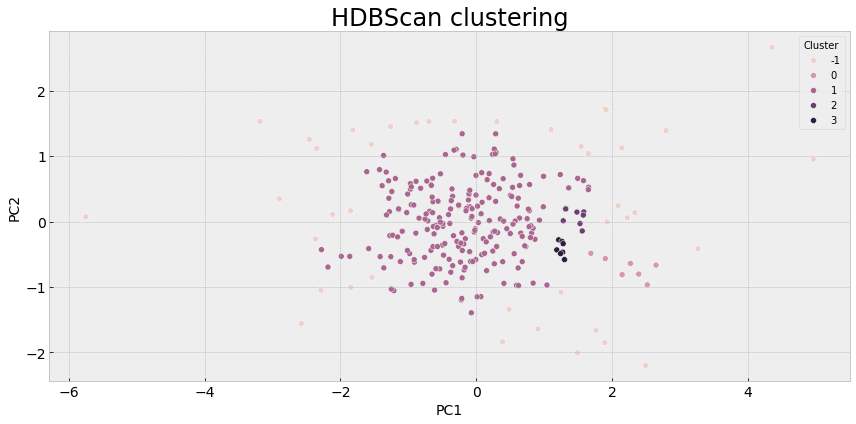

In [33]:
pca=PCA(n_components=2)

X_pca=pca.fit_transform(X_scaled)

plot_df=pd.DataFrame({'Date':df_clusters_hdbscan['Date'],'PC1':X_pca[:,0],'PC2':X_pca[:,1],'Cluster':clusters0})

plt.figure(figsize=(12,6))
plt.style.use("bmh")

sns.scatterplot(data=plot_df,x='PC1',y='PC2',hue='Cluster')

plt.xlabel('PC1',fontsize=14)
plt.ylabel('PC2',fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.title('HDBScan clustering',fontsize=24)
plt.tight_layout()

#uncomment to save for the presentation
plt.savefig("HDBSCAN.png", dpi=300, bbox_inches="tight",facecolor="white",transparent=False)

plt.show()

In [34]:
df_clusters_hdbscan_years={}
for i in df_clusters_hdbscan['Cluster'].sort_values().unique():
    years=df_clusters_hdbscan[df_clusters_hdbscan['Cluster']==i]['Date'].str[:4].unique()
    df_clusters_hdbscan_years[f'Cluster {i}']=years

In [35]:
df_clusters_hdbscan_PM=df_clusters_hdbscan.groupby("Cluster")["PM"].agg(["count", "mean", "median", "std", "min", "max"]).reset_index()
df_clusters_hdbscan_PM.columns=['Cluster','Count','Mean (%)','Median (%)','Volatility (%)','Min (%)','Max (%)']

df_clusters_hdbscan_PM.iloc[:,2:]=(df_clusters_hdbscan_PM.iloc[:,2:]*100)

df_clusters_hdbscan_PM['Risk-return ratio']=df_clusters_hdbscan_PM['Mean (%)']/df_clusters_hdbscan_PM['Volatility (%)']

In [36]:
df_clusters_hdbscan_IM=df_clusters_hdbscan.groupby("Cluster")["IM"].agg(["count", "mean", "median", "std", "min", "max"]).reset_index()
df_clusters_hdbscan_IM.columns=['Cluster','Count','Mean (%)','Median (%)','Volatility (%)','Min (%)','Max (%)']

df_clusters_hdbscan_IM.iloc[:,2:]=(df_clusters_hdbscan_IM.iloc[:,2:]*100)

df_clusters_hdbscan_IM['Risk-return ratio']=df_clusters_hdbscan_IM['Mean (%)']/df_clusters_hdbscan_IM['Volatility (%)']

In [37]:
df_clusters_hdbscan_PM

,Cluster,Count,Mean (%),Median (%),Volatility (%),Min (%),Max (%),Risk-return ratio
0,-1,41,2.982427,1.881770,11.941541,-23.979858,32.200323,0.249752
1,0,7,7.863811,8.010496,1.143044,6.465281,9.915255,6.879710
2,1,213,0.194843,-0.074424,4.335218,-11.591696,10.900628,0.044944
3,2,8,7.931030,7.841101,0.630134,6.863900,8.802642,12.586256
4,3,7,4.852664,4.706681,0.459239,4.324903,5.389532,10.566746


In [38]:
df_clusters_hdbscan_IM

,Cluster,Count,Mean (%),Median (%),Volatility (%),Min (%),Max (%),Risk-return ratio
0,-1,41,0.499702,1.287231,9.902847,-20.967398,18.150279,0.050460
1,0,7,11.590822,11.702481,1.743370,8.775470,13.663426,6.648514
2,1,213,-0.019269,-0.008759,3.277103,-8.143038,8.177810,-0.005880
3,2,8,5.820594,5.853982,0.767096,4.852872,7.034505,7.587829
4,3,7,6.884946,6.718340,0.480107,6.247275,7.690483,14.340428


### Because some HDBSCAN clusters contain only a small number of months, their summary statistics should be interpreted as descriptions of unusual regimes rather than stable long-run averages.

### Now we may briefly describe clusters we've got

In [39]:
df_clusters_hdbscan_years['Cluster -1']

array(['2004', '2005', '2007', '2008', '2009', '2010', '2011', '2012',
       '2013', '2015', '2016', '2017', '2018', '2020', '2021', '2022',
       '2025', '2026'], dtype=object)

### Cluster -1: noise and outliers

- by HDBScan method

In [40]:
df_clusters_hdbscan_years['Cluster 0']

array(['2006', '2010', '2020'], dtype=object)

### Cluster 0: precious metals and industrial materials boom

- high mean and median returns for PM and IM
- high min and max returns for PM and IM
- low volatility for both PM and IM

In [41]:
df_clusters_hdbscan_years['Cluster 1']

array(['1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005',
       '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021',
       '2022', '2023', '2024', '2025'], dtype=object)

### Cluster 1: high dispersion, plateau regime

- low, almost zero mean and median returns for both PM and IM
- almost zero risk-return ratio for both PM and IM
- wide range of returns (highly negative or highly positive) for both PM and IM
- medium volatility for both PM and IM

Dates ---> main state of PM and IM

In [42]:
df_clusters_hdbscan_years['Cluster 2']

array(['1999', '2003', '2009', '2016', '2020', '2024'], dtype=object)

### Cluster 2: precious metals boom

- very low volatility for PM and IM
- very high risk-return ratio for PM
- high min and max returns for PM and IM

Dates ---> Reaction to a recent crisis, immediate recovery afterwards

In [43]:
df_clusters_hdbscan_years['Cluster 3']

array(['2005', '2009', '2010', '2017', '2021', '2022'], dtype=object)

### Cluster 3: industrial materials boom

- very high risk-return ratio for IM
- high min and max return for PM and IM
- very high risk-return ratio for IM

Dates ---> Gradual industrial recovery after a crisis